<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 177.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 200.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 127.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 166.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 164.8 MB/s eta 0:00:00


Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [5]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [18]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests

# Load the dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

df.head()

Dataset loaded successfully!
Dataset shape: (65457, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [42]:
## Write your code here

#1 Count the number of duplicate rows in the dataset.
complete_duplicates = df.duplicated()
total_duplicates = complete_duplicates.sum()

print(f"Number to total duplicates rows in the csv file: {total_duplicates}")

if total_duplicates > 0:
    print("\n" + "="*100)
    print("DUPLICATE ROWS DETAILS")
    print(" "*100)

    
#2 Display the first few duplicate rows to understand their structure.

duplicate_rows = df[complete_duplicates]

for index, row in duplicate_rows.iterrows():
    print(f"\nRow Index: {index}")
    print(f"ResponseId: {row.get('ResponseId', 'N/A')}")
    print(f"MainBranch: {row.get('MainBranch', 'N/A')}")
    print(f"Age: {row.get('Age', 'N/A')}")
    print(f"Employment: {row.get('Employment', 'N/A')}")
    print(f"RemoteWork: {row.get('RemoteWork', 'N/A')}")
    print(f"Country: {row.get('Country', 'N/A')}")
    print(f"EdLevel: {row.get('EdLevel', 'N/A')}")
    print("-"*50)

Number to total duplicates rows in the csv file: 20

DUPLICATE ROWS DETAILS
                                                                                                    

Row Index: 65437
ResponseId: 1
MainBranch: I am a developer by profession
Age: Under 18 years old
Employment: Employed, full-time
RemoteWork: Remote
Country: United States of America
EdLevel: Primary/elementary school
--------------------------------------------------

Row Index: 65438
ResponseId: 2
MainBranch: I am a developer by profession
Age: 35-44 years old
Employment: Employed, full-time
RemoteWork: Remote
Country: United Kingdom of Great Britain and Northern Ireland
EdLevel: Bachelor’s degree (B.A., B.S., B.Eng., etc.)
--------------------------------------------------

Row Index: 65439
ResponseId: 3
MainBranch: I am a developer by profession
Age: 45-54 years old
Employment: Employed, full-time
RemoteWork: Remote
Country: United Kingdom of Great Britain and Northern Ireland
EdLevel: Master’s degree (M.A.

### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [43]:
## Write your code here
# Define pattern columns
pattern_cols = ['MainBranch', 'Employment', 'RemoteWork']

# Find patterns with multiple respondents
patterns = df.groupby(pattern_cols).size().reset_index(name='count')
patterns = patterns[patterns['count'] > 1].sort_values('count', ascending=False)

print(f"Found {len(patterns)} response patterns with multiple respondents\n")

# Display top patterns
for idx, row in patterns.head(10).iterrows():
    print(f"{row['MainBranch']} | {row['Employment']} | {row['RemoteWork']}")
    print(f"  → {row['count']} respondents\n")

Found 319 response patterns with multiple respondents

I am a developer by profession | Employed, full-time | Hybrid (some remote, some in-person)
  → 15288 respondents

I am a developer by profession | Employed, full-time | Remote
  → 12196 respondents

I am a developer by profession | Employed, full-time | In-person
  → 7118 respondents

I am a developer by profession | Independent contractor, freelancer, or self-employed | Remote
  → 2815 respondents

I am a developer by profession | Employed, full-time;Independent contractor, freelancer, or self-employed | Remote
  → 1754 respondents

I am not primarily a developer, but I write code sometimes as part of my work/studies | Employed, full-time | Hybrid (some remote, some in-person)
  → 1479 respondents

I am a developer by profession | Employed, full-time;Independent contractor, freelancer, or self-employed | Hybrid (some remote, some in-person)
  → 1169 respondents

I am a developer by profession | Independent contractor, freelancer,

### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


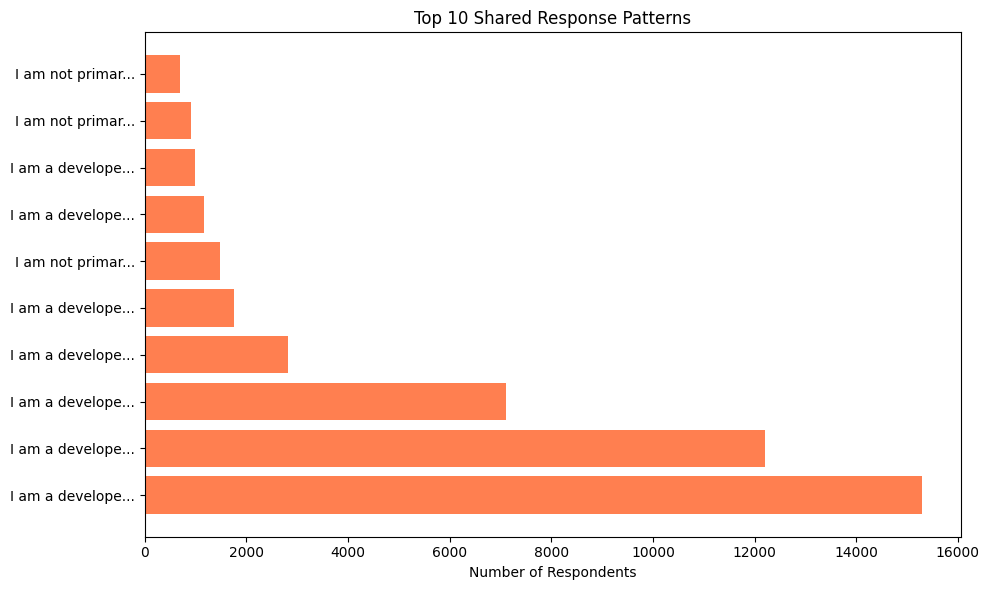

Found 319 patterns with multiple respondents
Top pattern has 15288 respondents


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and analyze
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv")

# Find patterns
pattern_cols = ['MainBranch', 'Employment', 'RemoteWork']
patterns = df.groupby(pattern_cols).size().reset_index(name='count')
patterns = patterns[patterns['count'] > 1].sort_values('count', ascending=False)

# Simple bar chart of top patterns
plt.figure(figsize=(10, 6))
top_10 = patterns.head(10)
plt.barh(range(len(top_10)), top_10['count'], color='coral')
plt.yticks(range(len(top_10)), [f"{row['MainBranch'][:15]}..." for _, row in top_10.iterrows()])
plt.xlabel('Number of Respondents')
plt.title('Top 10 Shared Response Patterns')
plt.tight_layout()
plt.show()

print(f"Found {len(patterns)} patterns with multiple respondents")
print(f"Top pattern has {patterns.iloc[0]['count']} respondents")

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


In [58]:
print("DUPLICATE HANDLING STRATEGY EVALUATION")
print("="*60)

# Check ResponseId uniqueness
if 'ResponseId' in df.columns:
    print(f"\nResponseId Analysis:")
    print(f"  Total rows: {len(df)}")
    print(f"  Unique ResponseIds: {df['ResponseId'].nunique()}")
    print(f"  Duplicate ResponseIds: {df['ResponseId'].duplicated().sum()}")
    
    # Show duplicate ResponseId examples
    dup_ids = df[df['ResponseId'].duplicated(keep=False)]
    if len(dup_ids) > 0:
        print(f"\n  Sample duplicate ResponseId values:")
        for rid in dup_ids['ResponseId'].unique()[:5]:
            count = len(dup_ids[dup_ids['ResponseId'] == rid])
            print(f"    ResponseId {rid}: appears {count} times")

else:
    print("\n✓ RECOMMENDATION: Remove complete row duplicates")
    print(f"  Impact: Will remove {df.duplicated().sum()} rows")

DUPLICATE HANDLING STRATEGY EVALUATION

ResponseId Analysis:
  Total rows: 65457
  Unique ResponseIds: 65437
  Duplicate ResponseIds: 20

  Sample duplicate ResponseId values:
    ResponseId 1: appears 2 times
    ResponseId 2: appears 2 times
    ResponseId 3: appears 2 times
    ResponseId 4: appears 2 times
    ResponseId 5: appears 2 times


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


In [60]:
import pandas as pd

# Load the dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

print("="*80)
print("DUPLICATE REMOVAL PROCESS DOCUMENTATION")
print("="*80)

# Step 1: Initial assessment
print("\nSTEP 1: INITIAL DATA ASSESSMENT")
print("-"*50)
print(f"Original dataset shape: {df.shape}")
print(f"Total rows before cleaning: {len(df)}")
print(f"Total columns: {len(df.columns)}")

# Step 2: Identify duplicates
print("\nSTEP 2: DUPLICATE IDENTIFICATION")
print("-"*50)

# Method 1: Complete row duplicates
complete_duplicates = df.duplicated()
complete_duplicate_count = complete_duplicates.sum()
print(f"Complete row duplicates: {complete_duplicate_count}")

# Method 2: ResponseId duplicates (if exists)
if 'ResponseId' in df.columns:
    responseid_duplicates = df['ResponseId'].duplicated()
    responseid_duplicate_count = responseid_duplicates.sum()
    print(f"ResponseId duplicates: {responseid_duplicate_count}")

# Method 3: Demographic duplicates
demo_cols = ['MainBranch', 'Age', 'Employment', 'Country']
available_demo = [col for col in demo_cols if col in df.columns]
demo_duplicates = df.duplicated(subset=available_demo).sum()
print(f"Demographic duplicates (based on {available_demo}): {demo_duplicates}")

# Step 3: Remove duplicates
print("\nSTEP 3: DUPLICATE REMOVAL")
print("-"*50)

# Create a clean copy
df_clean = df.copy()

# Remove duplicates based on ResponseId (preferred method)
if 'ResponseId' in df.columns:
    before_count = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=['ResponseId'], keep='first')
    after_count = len(df_clean)
    removed_count = before_count - after_count
    print(f"Removed {removed_count} duplicate records based on ResponseId")
    print(f"Kept first occurrence of each unique ResponseId")
else:
    # Fallback: remove complete duplicates
    before_count = len(df_clean)
    df_clean = df_clean.drop_duplicates(keep='first')
    after_count = len(df_clean)
    removed_count = before_count - after_count
    print(f"Removed {removed_count} complete duplicate records")

print(f"\nCleaned dataset shape: {df_clean.shape}")
print(f"Rows removed: {removed_count}")
print(f"Rows retained: {after_count}")

# Step 4: Verify removal
print("\nSTEP 4: VERIFICATION")
print("-"*50)

# Check if duplicates remain
if 'ResponseId' in df_clean.columns:
    remaining_duplicates = df_clean['ResponseId'].duplicated().sum()
    print(f"Remaining ResponseId duplicates: {remaining_duplicates}")
else:
    remaining_duplicates = df_clean.duplicated().sum()
    print(f"Remaining complete duplicates: {remaining_duplicates}")

if remaining_duplicates == 0:
    print("✓ Verification passed: No duplicates remain")
else:
    print("✗ Verification failed: Duplicates still present")

# Save cleaned dataset (optional)
df_clean.to_csv('survey_data_cleaned.csv', index=False)
print("\n✓ Cleaned dataset saved as 'survey_data_cleaned.csv'")

DUPLICATE REMOVAL PROCESS DOCUMENTATION

STEP 1: INITIAL DATA ASSESSMENT
--------------------------------------------------
Original dataset shape: (65457, 114)
Total rows before cleaning: 65457
Total columns: 114

STEP 2: DUPLICATE IDENTIFICATION
--------------------------------------------------
Complete row duplicates: 20
ResponseId duplicates: 20
Demographic duplicates (based on ['MainBranch', 'Age', 'Employment', 'Country']): 56214

STEP 3: DUPLICATE REMOVAL
--------------------------------------------------
Removed 20 duplicate records based on ResponseId
Kept first occurrence of each unique ResponseId

Cleaned dataset shape: (65437, 114)
Rows removed: 20
Rows retained: 65437

STEP 4: VERIFICATION
--------------------------------------------------
Remaining ResponseId duplicates: 0
✓ Verification passed: No duplicates remain

✓ Cleaned dataset saved as 'survey_data_cleaned.csv'


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
